# SIFT Classification with Bag of Visual Words (BoVW)

This notebook implements a classification pipeline for Traffic Sign ROIs using a **Bag of Visual Words (BoVW)** approach.
We start with pre-extracted SIFT features (10 descriptors per ROI, flattened into 1280 columns). We will:
1. Extract and reshape the original 10 SIFT descriptors (128D) for each ROI.
2. Use **K-Means Clustering** to build a visual vocabulary of 100 'visual words'.
3. Encode each ROI into a 100-bin frequency histogram.
4. Apply **StandardScaler** to normalize the histograms.
5. Train and evaluate **Random Forest**, **SVM**, **Gaussian Naive Bayes**, and **AdaBoost** models.
6. Perform **Cross-Validation** and plot a Model Comparison Bar Chart with error bars.
7. Visualize predictions using the best performing model.

In [44]:
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [45]:
def extract_label(filepath):
    basename = os.path.basename(filepath)
    filename = os.path.splitext(basename)[0]
    parts = filename.split('_')
    if len(parts) >= 3:
        return '_'.join(parts[2:])
    return filename

# Load dataset
data_path = 'data/features/all_feature_vectors.csv'
df = pd.read_csv(data_path)
print(f"Original Data shape: {df.shape}")

# Extract labels
df['label'] = df['roi_path'].apply(extract_label)
print("\nClass distribution:")
print(df['label'].value_counts())

Original Data shape: (1244, 1282)

Class distribution:
label
Speedlimits       783
Cross_Walk        200
Traffic_Lights    170
Stop_sign          91
Name: count, dtype: int64


In [46]:
# Features are columns f0 to f1279
feature_cols = [f'f{i}' for i in range(1280)]
X = df[feature_cols].values
y = df['label'].values
paths = df['roi_path'].values  # Keep track of paths for visualization

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, paths, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size (ROIs): {X_train.shape}, Test size (ROIs): {X_test.shape}")

Train size (ROIs): (995, 1280), Test size (ROIs): (249, 1280)


## Visual Vocabulary (K-Means Clustering)

We reshape the `X_train` data from `N_train x 1280` to `(N_train * 10) x 128`. This gives us the individual 128-dimensional SIFT descriptors. We then use K-Means to cluster these descriptors into 100 'visual words'.

In [47]:
# Reshape training data to extract individual 128D descriptors
num_train_rois = X_train.shape[0]
X_train_descriptors = X_train.reshape(-1, 128)
print(f"Reshaped Training Descriptors: {X_train_descriptors.shape}")

# Fit KMeans to build visual vocabulary
n_clusters = 100
print(f"Clustering {X_train_descriptors.shape[0]} descriptors into {n_clusters} visual words...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_train_descriptors)
print("Clustering completed.")

Reshaped Training Descriptors: (9950, 128)
Clustering 9950 descriptors into 100 visual words...
Clustering completed.


## Histogram Encoding

Now we convert each ROI's 10 descriptors into a 100-bin histogram representing the frequencies of the visual words it contains.

In [48]:
def build_bovw_histograms(X, kmeans_model, n_clusters):
    num_rois = X.shape[0]
    # Reshape to descriptors
    X_desc = X.reshape(-1, 128)
    
    # Predict visual word for each descriptor
    words = kmeans_model.predict(X_desc)
    
    # Group back by ROI to build histograms
    words_per_roi = words.reshape(num_rois, 10)
    
    histograms = np.zeros((num_rois, n_clusters))
    for i in range(num_rois):
        # Count frequency of each word for the i-th ROI
        counts = np.bincount(words_per_roi[i], minlength=n_clusters)
        histograms[i] = counts
        
    return histograms

# Build histograms for Train and Test sets
X_train_hist = build_bovw_histograms(X_train, kmeans, n_clusters)
X_test_hist = build_bovw_histograms(X_test, kmeans, n_clusters)

print(f"Train histograms shape: {X_train_hist.shape}")
print(f"Test histograms shape: {X_test_hist.shape}")

Train histograms shape: (995, 100)
Test histograms shape: (249, 100)


## Regularization

Apply `StandardScaler` to ensure all features are on the same scale, which is especially important for the SVM and distance-based models.

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hist)
X_test_scaled = scaler.transform(X_test_hist)
print("Standard scaling applied.")

Standard scaling applied.


## Model Training and Evaluation

We train and evaluate four models:
1. **Gaussian Naive Bayes**
2. **AdaBoost Classifier**
3. **Random Forest Classifier**
4. **Support Vector Machine (SVM)**

In [50]:
models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42)
}

best_acc = 0
best_model_name = ""
best_model = None
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = model

print(f"\nTraining complete! Best model is {best_model_name} with Test Accuracy: {best_acc:.4f}")

Training Gaussian Naive Bayes...
Training AdaBoost...
Training Random Forest...
Training SVM...

Training complete! Best model is Random Forest with Test Accuracy: 0.8313


### Comprehensive Evaluations (Accuracy, Reports, Confusion Matrices)

Gaussian Naive Bayes Accuracy: 0.6586
Classification Report:
                precision    recall  f1-score   support

    Cross_Walk       0.64      0.70      0.67        40
   Speedlimits       0.98      0.74      0.84       157
     Stop_sign       0.22      0.89      0.35        18
Traffic_Lights       0.29      0.12      0.17        34

      accuracy                           0.66       249
     macro avg       0.53      0.61      0.51       249
  weighted avg       0.78      0.66      0.69       249

AdaBoost Accuracy: 0.8273
Classification Report:
                precision    recall  f1-score   support

    Cross_Walk       0.96      0.55      0.70        40
   Speedlimits       0.81      0.97      0.88       157
     Stop_sign       1.00      0.44      0.62        18
Traffic_Lights       0.80      0.71      0.75        34

      accuracy                           0.83       249
     macro avg       0.89      0.67      0.74       249
  weighted avg       0.84      0.83      0.81

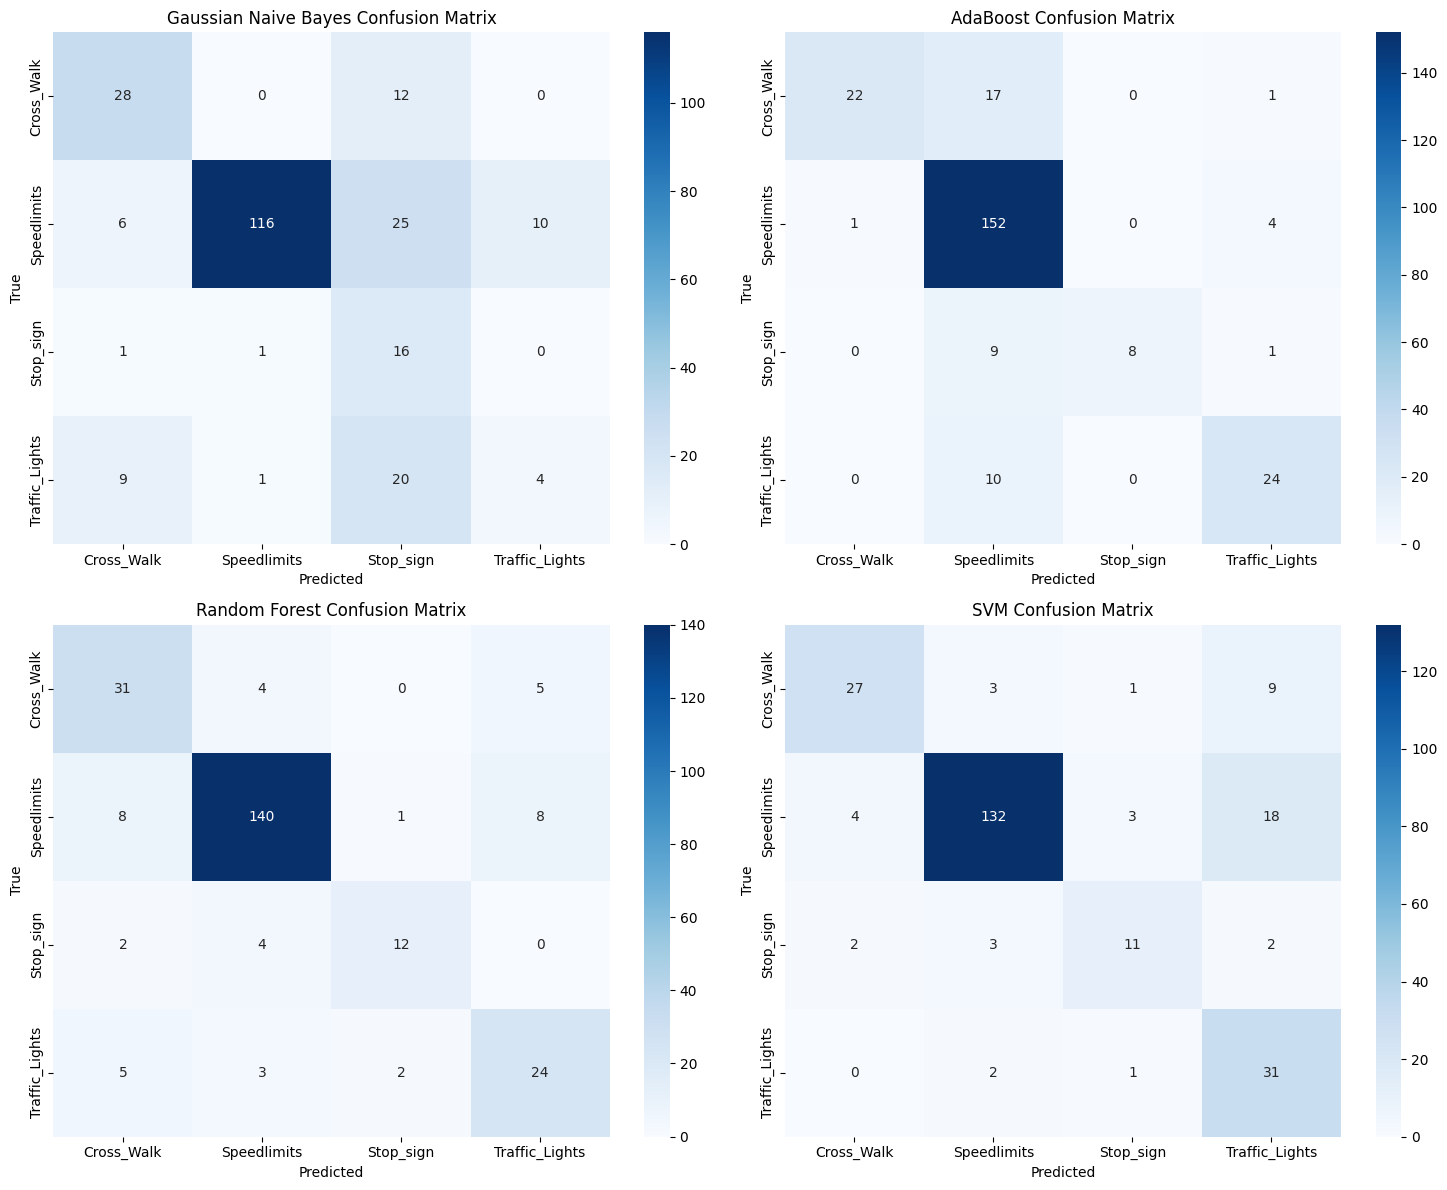

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=models[name].classes_, yticklabels=models[name].classes_)
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.show()

## Cross-Validation and Model Comparison

To ensure models are generalizing well across the dataset, we perform 5-fold cross-validation on the training set and plot the mean accuracy with error bars showing the standard deviation.

Running 5-fold Cross-Validation...
Gaussian Naive Bayes CV Accuracy: 0.6834 +/- 0.0196
AdaBoost CV Accuracy: 0.8010 +/- 0.0275
Random Forest CV Accuracy: 0.8523 +/- 0.0176
SVM CV Accuracy: 0.8362 +/- 0.0350


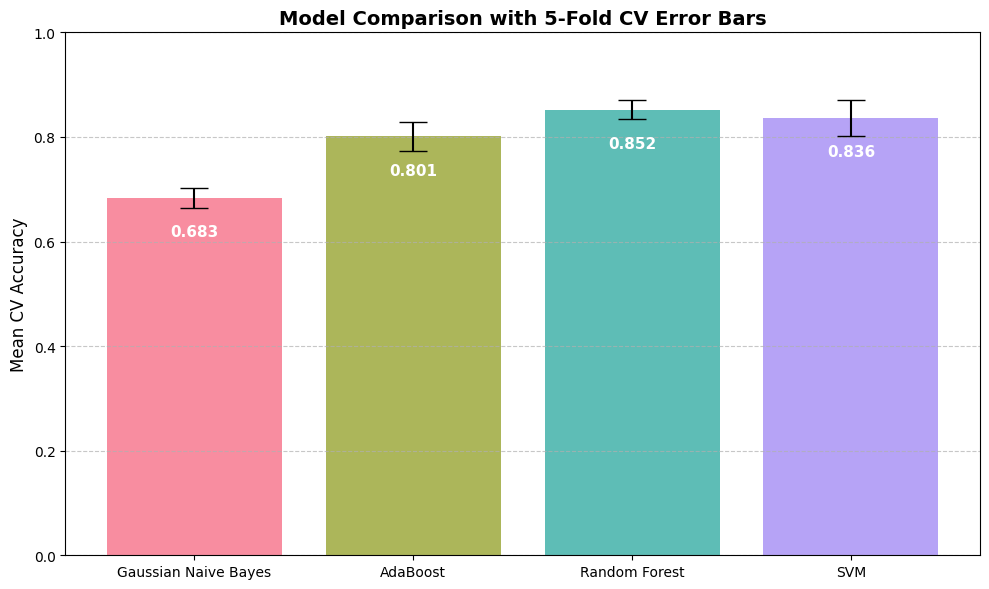

In [52]:
cv_means = []
cv_stds = []
model_names = list(models.keys())

print("Running 5-fold Cross-Validation...")
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_means.append(np.mean(scores))
    cv_stds.append(np.std(scores))
    print(f"{name} CV Accuracy: {np.mean(scores):.4f} +/- {np.std(scores):.4f}")

# Plotting the bar chart with error bars
plt.figure(figsize=(10, 6))
colors = sns.color_palette("husl", len(model_names))
bars = plt.bar(model_names, cv_means, yerr=cv_stds, capsize=10, color=colors, alpha=0.8)

plt.title('Model Comparison with 5-Fold CV Error Bars', fontsize=14, fontweight='bold')
plt.ylabel('Mean CV Accuracy', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for bar, mean in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, mean - 0.05, f'{mean:.3f}', 
             ha='center', va='top', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Visualization of Predictions (Best Model)

Let's visualize a random sample of the test set, showing the original image alongside the prediction from our best-performing model.

Visualizing predictions using: Random Forest


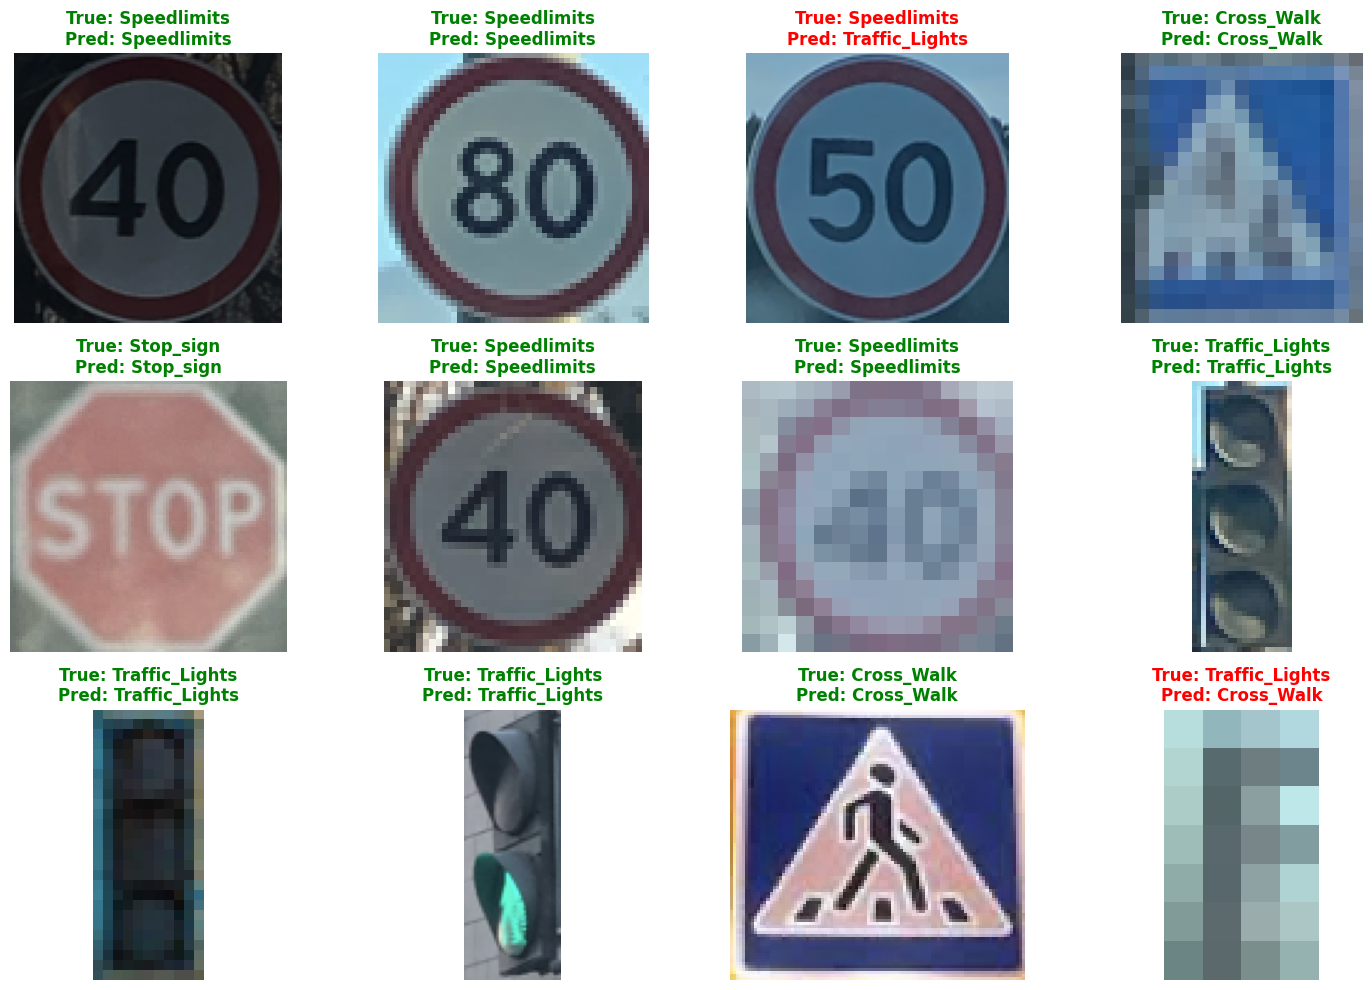

In [59]:
print(f"Visualizing predictions using: {best_model_name}")

# Randomly select 6 samples from the test set
num_samples = 12
indices = random.sample(range(len(X_test_scaled)), num_samples)

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img_path = paths_test[idx]
    true_label = y_test[idx]
    
    # Predict using the best model
    features = X_test_scaled[idx].reshape(1, -1)
    pred_label = best_model.predict(features)[0]
    
    # Display image
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
    else:
        axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        
    # Green title if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()